# Vida que se delata por cómo se reparte

Si encontráramos un meteorito con 27 tipos de aminoácidos, ¿diríamos que hay vida?
Bennu — la roca traída de regreso por la sonda OSIRIS-REx en 2023 — tiene exactamente eso.
Y, aún así, es abiótica.

Un nuevo paper en *Nature Astronomy* propone una bisagra: la vida no se distingue por **cuántos** tipos
de moléculas hay, sino por **cómo se reparten**. Aquí abrimos sus datos para verlo con nuestros ojos.

---

**Paper**: [Molecular diversity as a biosignature](https://doi.org/10.1038/s41550-026-02864-z) · Yoffe et al., *Nature Astronomy* (2026-05-11)
**Datos**: [Zenodo — abundancias y errores](https://doi.org/10.5281/zenodo.16566388)
**Video**: [Pendiente]

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-12-diversidad-molecular-biosignatura/notebook.ipynb)


## La pregunta que aterriza esto

Las misiones planetarias pueden medir abundancias relativas de moléculas — eso es accesible.
Lo que no pueden hacer fácil es medir quiralidad o composición isotópica con la precisión que la biología
demanda en otro mundo. El equipo de Yoffe et al. junta 69 muestras de aminoácidos: 30 abióticas
(meteoritos, simulaciones, química prebiótica), 28 bióticas (microbios, fósiles antiguos, suelos),
y 11 mixtas (donde no se puede separar la fracción viva).

Sobre cada muestra calculan la **entropía de Shannon** — una medida que sube cuando las moléculas
se reparten parejo, y baja cuando una o dos dominan. Su tesis: la vida tiende a repartir, la química
abiótica tiende a concentrarse. Veámoslo.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_ABIOTIC = '#D97706'       # Ámbar — química sin vida
COLOR_BIOTIC  = '#059669'       # Esmeralda — vida confirmada
COLOR_MIXED   = '#7C3AED'       # Violeta — origen ambiguo
COLOR_ALERTA  = '#DC2626'
COLOR_DATOS   = '#2563EB'
FUENTE = 'Fuente: Yoffe et al. (2026), Nature Astronomy | Datos: Zenodo 16566388 (CC-BY-4.0)'

# Setup
import os, sys, urllib.request, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local en el repo o fallback a raw GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file,
        )
plt.style.use(style_file)

# Carga de datos
aa = pd.read_csv('datos/AA_diversity_per_sample.csv')
fa = pd.read_csv('datos/FA_diversity_per_sample.csv')
aa_ab = pd.read_csv('datos/AA_abundances.csv')

print(f'Aminoácidos: {len(aa)} muestras')
print(aa['class_label'].value_counts().to_string())
print(f'\nÁcidos grasos: {len(fa)} muestras')
print(fa['class_label'].value_counts().to_string())


Aminoácidos: 69 muestras
class_label
abiotic    30
biotic     28
mixed      11

Ácidos grasos: 34 muestras
class_label
biotic     18
abiotic    16


## Aquí está.

Cada punto es una muestra. El eje vertical es la diversidad de Shannon de sus aminoácidos.
Las medias y errores son media ± SEM por clase.


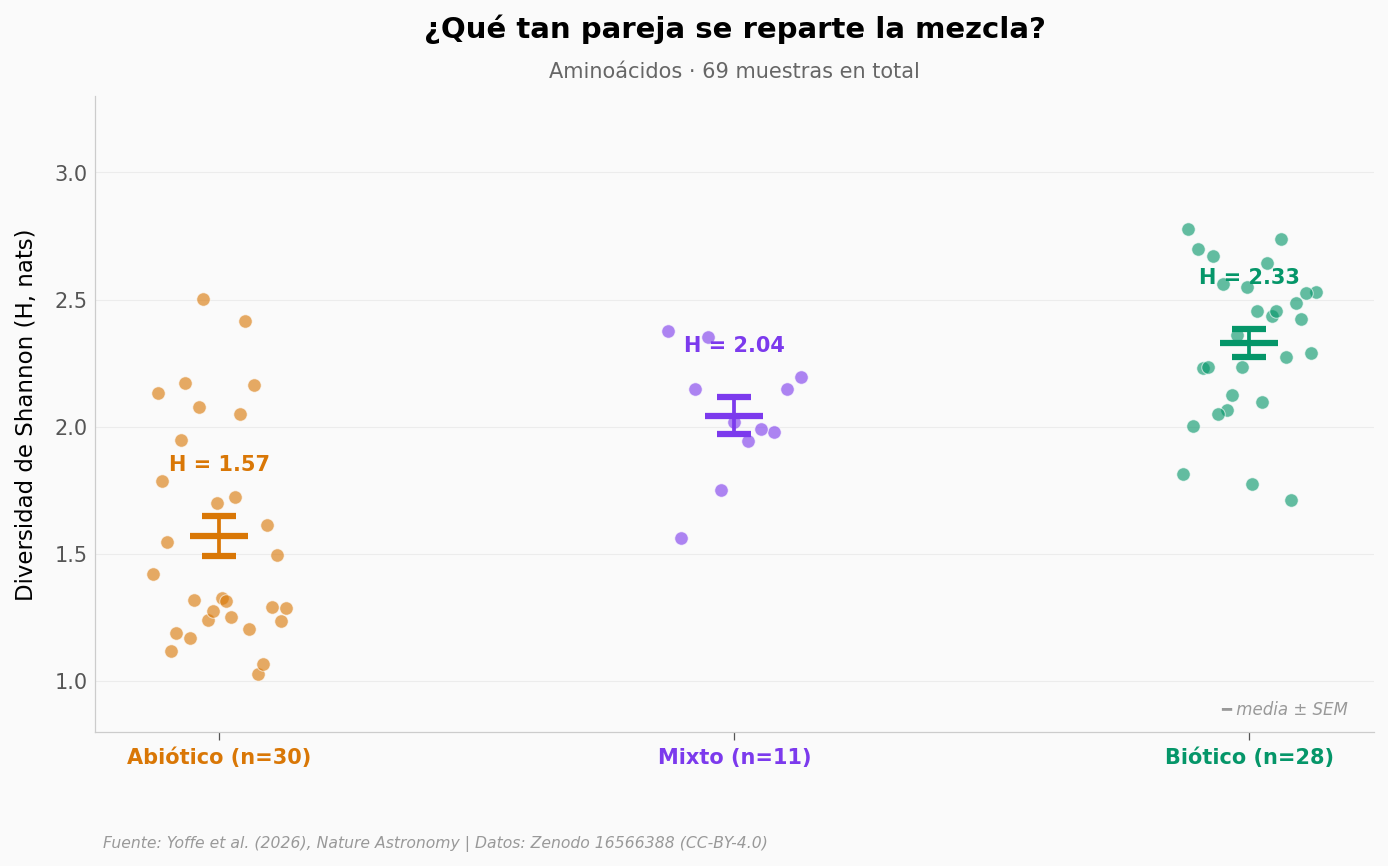

In [2]:
fig, ax = plt.subplots(figsize=(11, 5.5))

groups = [
    ('Abiótico',  aa[aa['class_label']=='abiotic']['H'].values,  COLOR_ABIOTIC, 0),
    ('Mixto',     aa[aa['class_label']=='mixed']['H'].values,    COLOR_MIXED,   1.4),
    ('Biótico',   aa[aa['class_label']=='biotic']['H'].values,   COLOR_BIOTIC,  2.8),
]

np.random.seed(42)
for label, vals, color, pos in groups:
    n = len(vals)
    x_jitter = np.linspace(pos - 0.18, pos + 0.18, n)
    np.random.shuffle(x_jitter)
    ax.scatter(x_jitter, vals, color=color, s=42, alpha=0.62,
               edgecolors='white', linewidths=0.5, zorder=5)
    mean = vals.mean()
    sem  = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(pos, mean, yerr=sem, fmt='_', color=color,
                markersize=28, markeredgewidth=3,
                capsize=8, capthick=1.6, zorder=6)
    ax.text(pos, mean + sem + 0.18, f'H = {mean:.2f}',
            ha='center', fontsize=10, fontweight='bold', color=color, zorder=7)

ax.set_xticks([0, 1.4, 2.8])
ax.set_xticklabels(
    [f'Abiótico (n={len(groups[0][1])})',
     f'Mixto (n={len(groups[1][1])})',
     f'Biótico (n={len(groups[2][1])})'],
    fontsize=10, fontweight='bold',
)
for tick, (_, _, color, _) in zip(ax.get_xticklabels(), groups):
    tick.set_color(color)

ax.set_ylabel('Diversidad de Shannon (H, nats)', fontsize=11)
ax.set_ylim(0.8, 3.3)

ax.set_title('¿Qué tan pareja se reparte la mezcla?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Aminoácidos · 69 muestras en total',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.02, '━ media ± SEM',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/diversidad_por_clase.png', dpi=200, bbox_inches='tight')
plt.show()


La distancia entre las nubes verde y ámbar es la pieza central. Las muestras bióticas
se concentran arriba (mediana ≈ 2,39); las abióticas, abajo (mediana ≈ 1,37). El solapamiento existe
— hay meteoritos como Murchison y Allende con diversidad alta —, pero la nube de la vida vive
separada de la nube del polvo cósmico.

La diferencia, además de visible, es estadísticamente fuerte:


In [3]:
# Test Mann-Whitney U (one-sided: biotic > abiotic) — no asume normalidad
H_biotic  = aa[aa['class_label']=='biotic']['H'].values
H_abiotic = aa[aa['class_label']=='abiotic']['H'].values

u_stat, p_val = stats.mannwhitneyu(H_biotic, H_abiotic, alternative='greater')

# Cohen's d (pooled) — tamaño del efecto
n1, n2 = len(H_biotic), len(H_abiotic)
s_pool = np.sqrt(((n1-1)*H_biotic.var(ddof=1) + (n2-1)*H_abiotic.var(ddof=1)) / (n1+n2-2))
cohen_d = (H_biotic.mean() - H_abiotic.mean()) / s_pool

print(f'Biótico:  media H = {H_biotic.mean():.3f}  (n={n1})')
print(f'Abiótico: media H = {H_abiotic.mean():.3f}  (n={n2})')
print(f'Diferencia: {H_biotic.mean() - H_abiotic.mean():+.3f} nats '
      f'({100*(H_biotic.mean() - H_abiotic.mean())/H_abiotic.mean():.1f}%)')
print(f'Mann-Whitney U = {u_stat:.0f},  p = {p_val:.2e}')
print(f"Cohen's d (pooled) = {cohen_d:.2f}  (d>0,8 = efecto grande)")


Biótico:  media H = 2.328  (n=28)
Abiótico: media H = 1.568  (n=30)
Diferencia: +0.760 nats (48.5%)
Mann-Whitney U = 766,  p = 3.80e-08
Cohen's d (pooled) = 2.06  (d>0,8 = efecto grande)


## La paradoja: lo abiótico tiene más tipos

La intuición ingenua dice "más vida = más variedad química". Los datos dicen lo contrario:
las muestras abióticas tienen, en promedio, **más tipos distintos** de aminoácidos que las bióticas
(16,3 vs 14,1). ¿Cómo cuadra eso con que la vida sea "más diversa"?

La clave está en cómo se reparten esos tipos. Veamos.


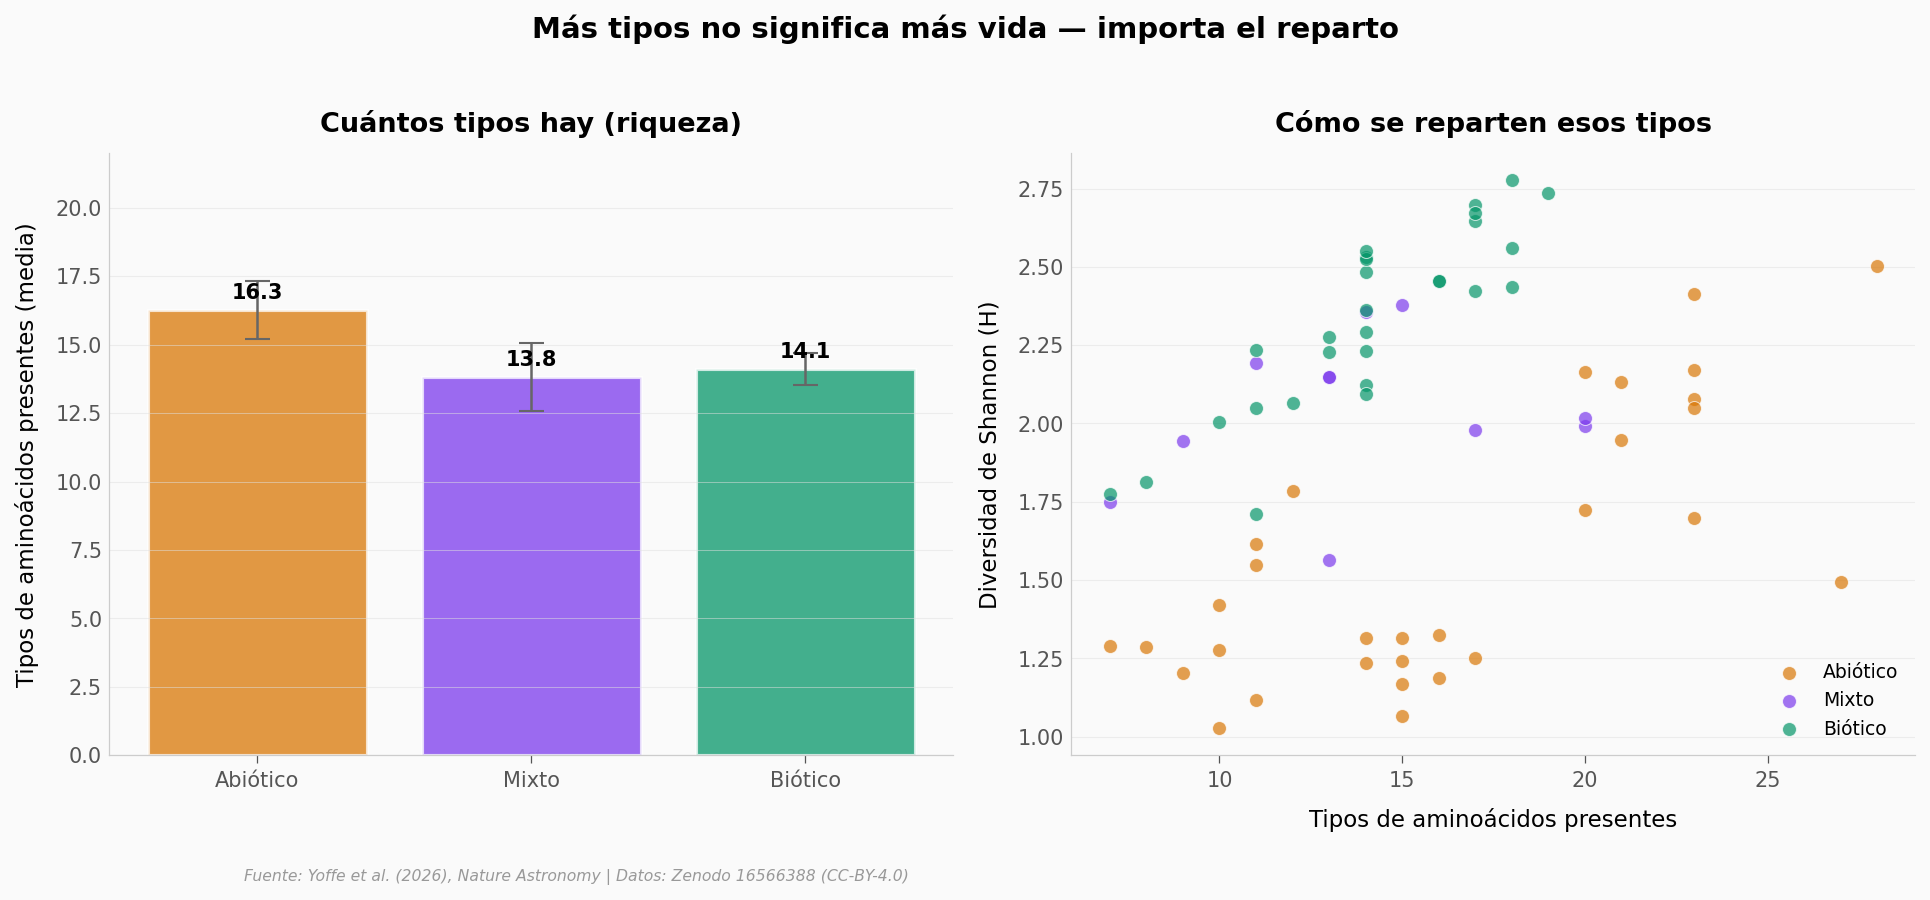

In [4]:
# Calcular tipos presentes (n_present) por clase y plotear vs H
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# --- Panel A: barras de tipos promedio (richness) ---
ax = axes[0]
class_order = ['abiotic', 'mixed', 'biotic']
labels_es   = ['Abiótico', 'Mixto', 'Biótico']
colors      = [COLOR_ABIOTIC, COLOR_MIXED, COLOR_BIOTIC]

richness_means = [aa[aa['class_label']==c]['n_present'].mean() for c in class_order]
richness_sems  = [aa[aa['class_label']==c]['n_present'].std(ddof=1)
                  / np.sqrt(len(aa[aa['class_label']==c])) for c in class_order]

bars = ax.bar(labels_es, richness_means, yerr=richness_sems,
              color=colors, alpha=0.75, edgecolor='white', linewidth=1.5,
              capsize=6, error_kw={'ecolor': '#666666', 'lw': 1.2})
for bar, mean in zip(bars, richness_means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.4, f'{mean:.1f}',
            ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Tipos de aminoácidos presentes (media)', fontsize=11)
ax.set_ylim(0, 22)
ax.set_title('Cuántos tipos hay (riqueza)', fontsize=13, fontweight='bold', pad=10)

# --- Panel B: relación tipos vs diversidad ---
ax = axes[1]
for c, label, color in zip(class_order, labels_es, colors):
    sub = aa[aa['class_label']==c]
    ax.scatter(sub['n_present'], sub['H'],
               color=color, s=45, alpha=0.7,
               edgecolors='white', linewidths=0.5,
               label=label, zorder=5)

ax.set_xlabel('Tipos de aminoácidos presentes', fontsize=11)
ax.set_ylabel('Diversidad de Shannon (H)', fontsize=11)
ax.set_title('Cómo se reparten esos tipos', fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=9, loc='lower right', framealpha=0.9)

fig.suptitle('Más tipos no significa más vida — importa el reparto',
             fontsize=14, fontweight='bold', y=1.02)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/riqueza_vs_diversidad.png', dpi=200, bbox_inches='tight')
plt.show()


Lo que ven los datos: cuando los puntos ámbar tienen muchos tipos, su H se queda corto.
Eso pasa porque dos aminoácidos — glicina y alanina — copan la fracción y dejan al resto en migajas.
Cuando los puntos verdes tienen pocos tipos, su H ya es alta. La vida no acumula moléculas raras,
las reparte.

Para hacerlo concreto, miremos a Bennu — el cuerpo asteroidal del que la NASA trajo muestras
en 2023, hoy guardado en Houston.


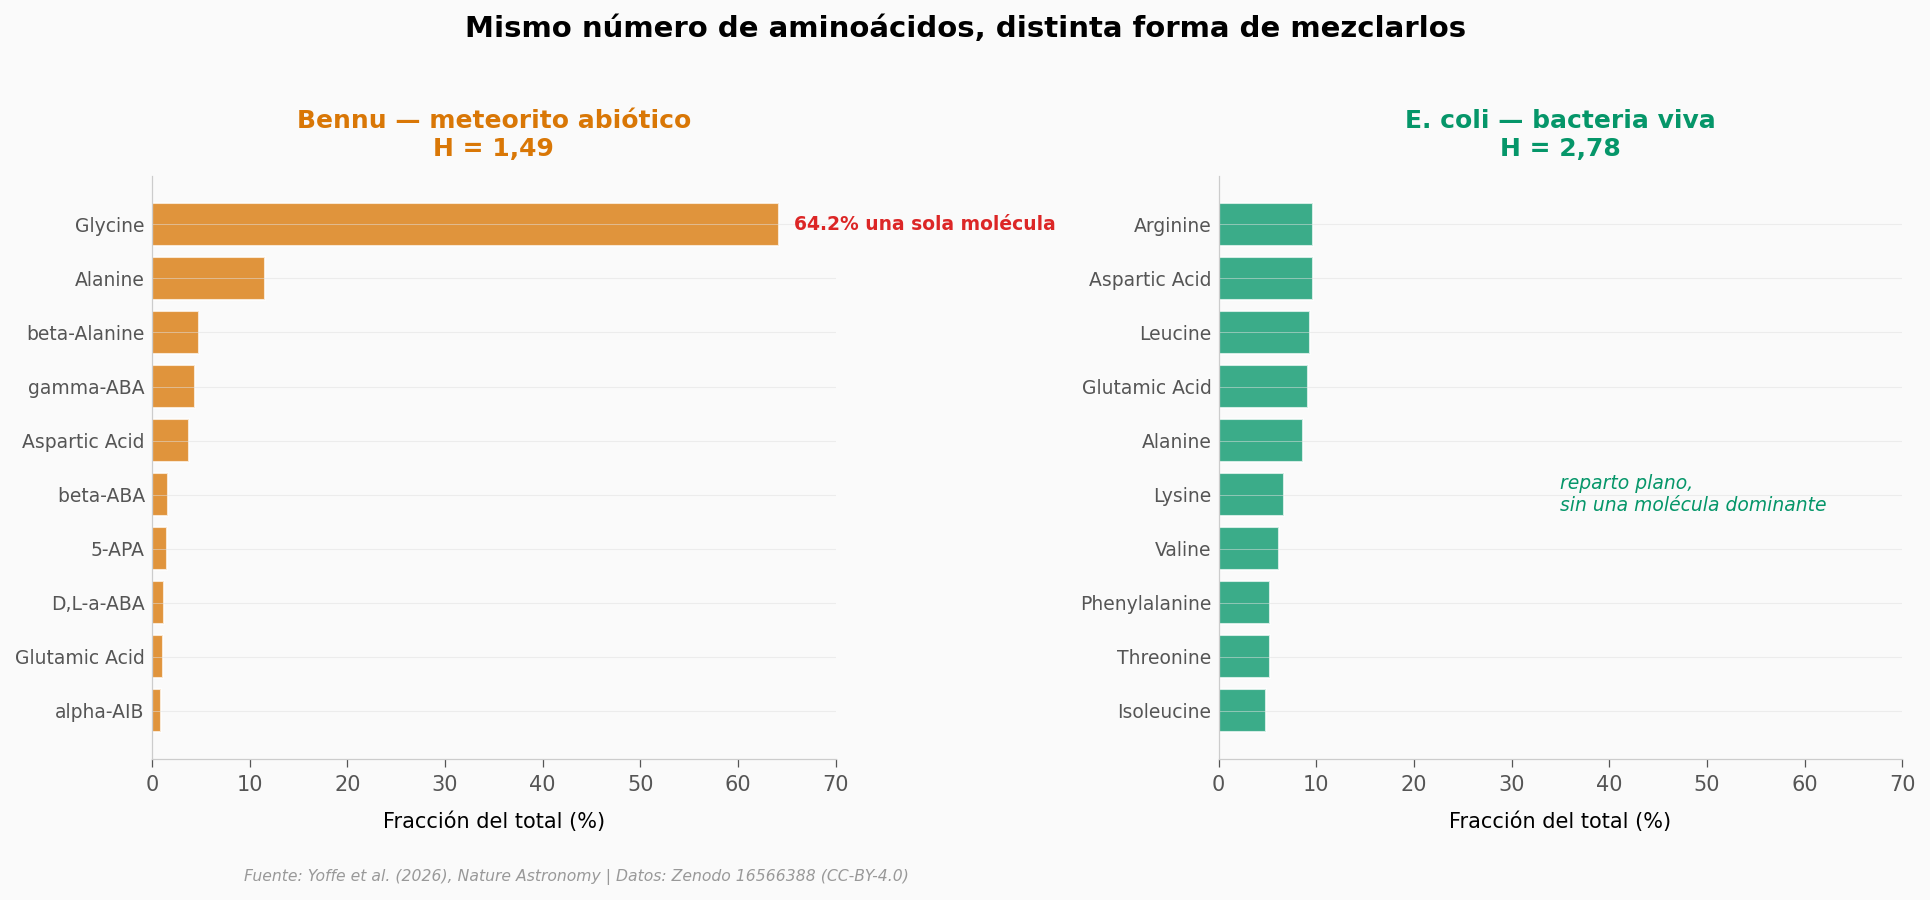

In [5]:
# Composición de Bennu vs la suma promedio de muestras bióticas
bennu_col = 'Bennu (CI) (Glavin+25)'

# Obtener abundancias: las dos primeras filas son meta (class label / stat model)
aa_data = aa_ab.iloc[2:].copy()
aa_data['Amino Acid'] = aa_data['Amino Acid'].astype(str)

# Bennu — tomar solo aminoácidos con valor numérico > 0
bennu = aa_data[['Amino Acid', bennu_col]].copy()
bennu[bennu_col] = pd.to_numeric(bennu[bennu_col], errors='coerce')
bennu = bennu.dropna()
bennu = bennu[bennu[bennu_col] > 0].copy()
bennu['frac'] = bennu[bennu_col] / bennu[bennu_col].sum()
bennu_top = bennu.sort_values('frac', ascending=False).head(10)

# Una muestra biótica representativa: E. Coli (paradigma de microbio vivo)
ecoli_col = [c for c in aa_ab.columns if 'E. Coli' in c or 'Coli' in c][0]
ecoli = aa_data[['Amino Acid', ecoli_col]].copy()
ecoli[ecoli_col] = pd.to_numeric(ecoli[ecoli_col], errors='coerce')
ecoli = ecoli.dropna()
ecoli = ecoli[ecoli[ecoli_col] > 0].copy()
ecoli['frac'] = ecoli[ecoli_col] / ecoli[ecoli_col].sum()
ecoli_top = ecoli.sort_values('frac', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Bennu
ax = axes[0]
y = np.arange(len(bennu_top))
ax.barh(y, bennu_top['frac'].values * 100,
        color=COLOR_ABIOTIC, alpha=0.78, edgecolor='white', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(bennu_top['Amino Acid'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Fracción del total (%)', fontsize=10)
ax.set_title(f'Bennu — meteorito abiótico\nH = 1,49', fontsize=12,
             fontweight='bold', color=COLOR_ABIOTIC, pad=10)
ax.set_xlim(0, 70)
# Anotar dominancia de la glicina
gly_pct = bennu_top[bennu_top['Amino Acid'].str.contains('Gly', case=False)]['frac'].values
if len(gly_pct) > 0:
    ax.text(gly_pct[0]*100 + 1.5, 0, f'{gly_pct[0]*100:.1f}% una sola molécula',
            fontsize=9, color=COLOR_ALERTA, fontweight='bold', va='center')

# E. Coli
ax = axes[1]
y = np.arange(len(ecoli_top))
ax.barh(y, ecoli_top['frac'].values * 100,
        color=COLOR_BIOTIC, alpha=0.78, edgecolor='white', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(ecoli_top['Amino Acid'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Fracción del total (%)', fontsize=10)
ax.set_title('E. coli — bacteria viva\nH = 2,78', fontsize=12,
             fontweight='bold', color=COLOR_BIOTIC, pad=10)
ax.set_xlim(0, 70)
ax.text(35, len(ecoli_top)/2, 'reparto plano,\nsin una molécula dominante',
        fontsize=9, color=COLOR_BIOTIC, style='italic', va='center')

fig.suptitle('Mismo número de aminoácidos, distinta forma de mezclarlos',
             fontsize=14, fontweight='bold', y=1.02)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/bennu_vs_ecoli.png', dpi=200, bbox_inches='tight')
plt.show()


## Y los iconos de la historia: ¿qué dicen?

Miremos cómo caen las muestras que cualquier curso de astrobiología cita:
- **Bennu, Ryugu, Murchison**: meteoritos carbonosos famosos.
- **Bitter Springs (~850 millones de años), Gunflint (~1880 Ma), Fig Tree (~3260 Ma)**:
  esteras microbianas fosilizadas — entre las pruebas más antiguas de vida en la Tierra.
- **Enceladus**: una simulación de qué encontraríamos si la luna helada de Saturno tuviera vida vs si no.


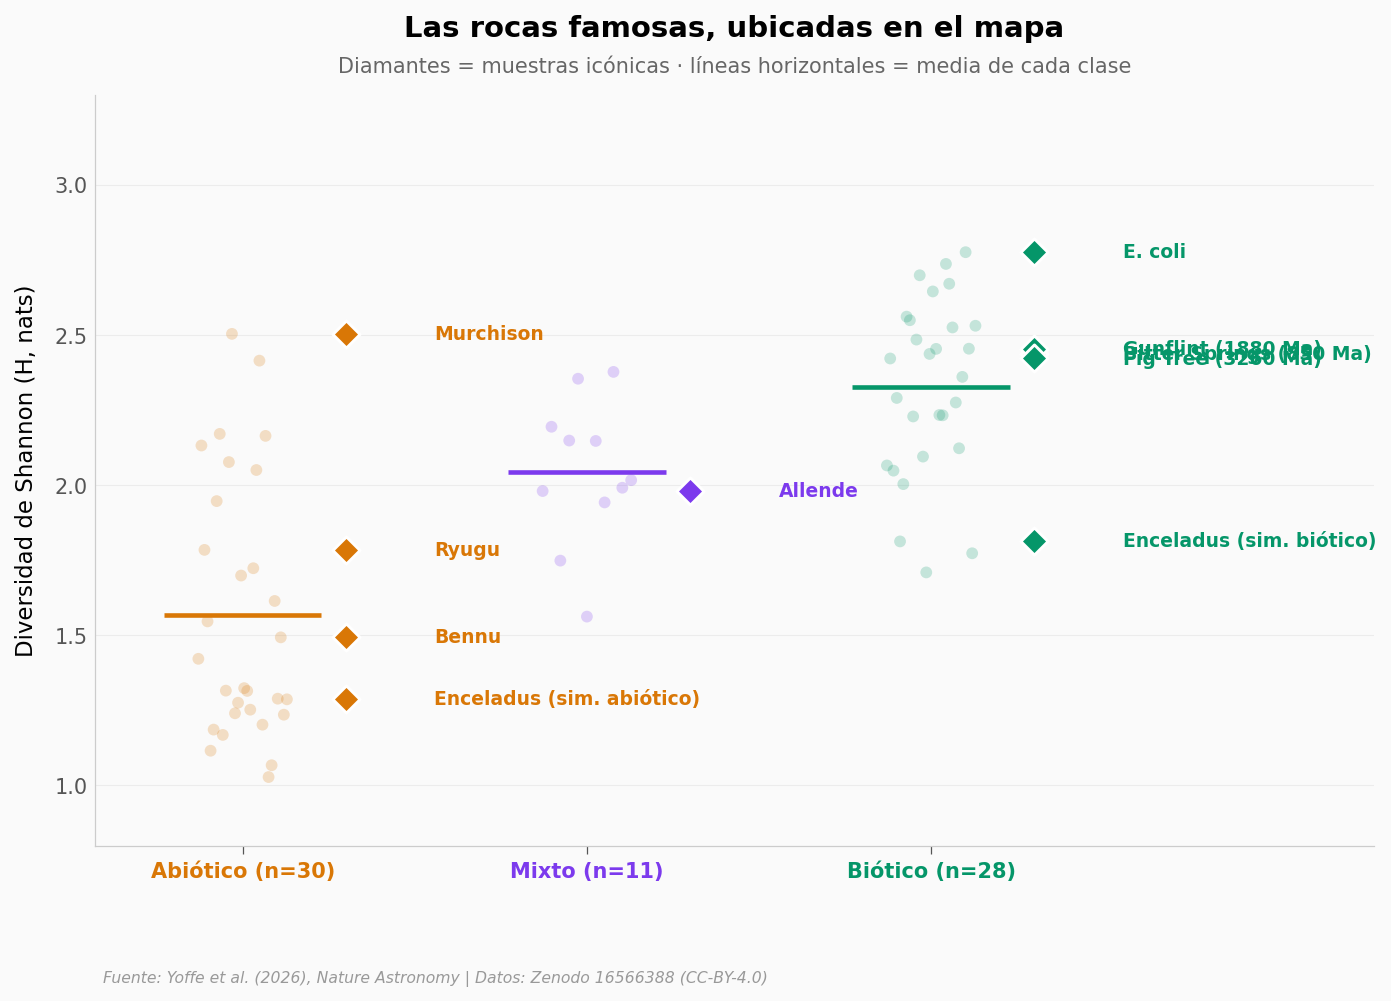

In [6]:
# Marcar muestras icónicas sobre el strip plot principal
famous = {
    'Bennu (CI) (Glavin+25)':            ('abiotic', 'Bennu',       0.42),
    'Ryugu (CI) (Glavin+22)':            ('abiotic', 'Ryugu',       0.42),
    'Murchison (CM2) (Glavin+11)':       ('abiotic', 'Murchison',   0.42),
    'Allende (CV3) (Cronin & Pizzarello)':('mixed',   'Allende',     1.82),
    'Enceladus Abiotic':                 ('abiotic', 'Enceladus (sim. abiótico)', 0.42),
    'Enceladus Biotic':                  ('biotic',  'Enceladus (sim. biótico)',  3.22),
    'E. Coli (Bada+98 in Carroll+02)':   ('biotic',  'E. coli',      3.22),
    'Bitter Springs Chert (Brocks+03)':  ('biotic',  'Bitter Springs (850 Ma)',  3.22),
    'Gunflint Chert (Hahn+88)':          ('biotic',  'Gunflint (1880 Ma)',       3.22),
    'Fig Tree Chert (Sephton+04)':       ('biotic',  'Fig Tree (3260 Ma)',       3.22),
}

# Mapear nombres del fact sheet a los del CSV (algunos varían)
samples_in_csv = aa['sample'].tolist()
match_map = {}
for key in famous:
    # Búsqueda permisiva por substring
    matches = [s for s in samples_in_csv if key.split(' (')[0] in s]
    if matches:
        match_map[matches[0]] = famous[key]

fig, ax = plt.subplots(figsize=(11, 6.5))

# Strip plot de fondo (puntos atenuados)
for c, label, color, pos in [('abiotic', 'Abiótico', COLOR_ABIOTIC, 0),
                              ('mixed',   'Mixto',   COLOR_MIXED,   1.4),
                              ('biotic',  'Biótico', COLOR_BIOTIC,  2.8)]:
    sub = aa[aa['class_label']==c]
    n = len(sub)
    np.random.seed(42)
    x_jit = np.linspace(pos - 0.18, pos + 0.18, n)
    np.random.shuffle(x_jit)
    ax.scatter(x_jit, sub['H'].values, color=color, s=32, alpha=0.22,
               edgecolors='none', zorder=3)
    mean = sub['H'].mean()
    ax.hlines(mean, pos - 0.32, pos + 0.32, color=color, lw=2.2, zorder=5)

# Anotar famous samples por encima
np.random.seed(7)
offset_x = 0
last_y_left, last_y_right = -10, -10
for csv_name, (cls, friendly, pos) in match_map.items():
    row = aa[aa['sample']==csv_name].iloc[0]
    H = row['H']
    color = COLOR_ABIOTIC if cls=='abiotic' else (COLOR_BIOTIC if cls=='biotic' else COLOR_MIXED)
    # Diamante grande
    ax.scatter([pos], [H], marker='D', color=color, s=85,
               edgecolors='white', linewidths=1.4, zorder=10)
    # Texto a la derecha del punto
    ax.annotate(friendly,
                xy=(pos, H), xytext=(pos + 0.36, H),
                fontsize=9, fontweight='bold', color=color,
                va='center', ha='left', zorder=12)

ax.set_xticks([0, 1.4, 2.8])
ax.set_xticklabels(['Abiótico (n=30)', 'Mixto (n=11)', 'Biótico (n=28)'],
                   fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(),
                       [COLOR_ABIOTIC, COLOR_MIXED, COLOR_BIOTIC]):
    tick.set_color(color)

ax.set_ylabel('Diversidad de Shannon (H, nats)', fontsize=11)
ax.set_ylim(0.8, 3.3)
ax.set_xlim(-0.6, 4.6)

ax.set_title('Las rocas famosas, ubicadas en el mapa',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Diamantes = muestras icónicas · líneas horizontales = media de cada clase',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/famous_samples.png', dpi=200, bbox_inches='tight')
plt.show()


## ¿Qué tan rara sería una "vida" con la diversidad de Bennu?

Pensemos al revés: si Bennu fuera vida, ¿cuántas muestras bióticas conocidas tendrían menos diversidad que él?


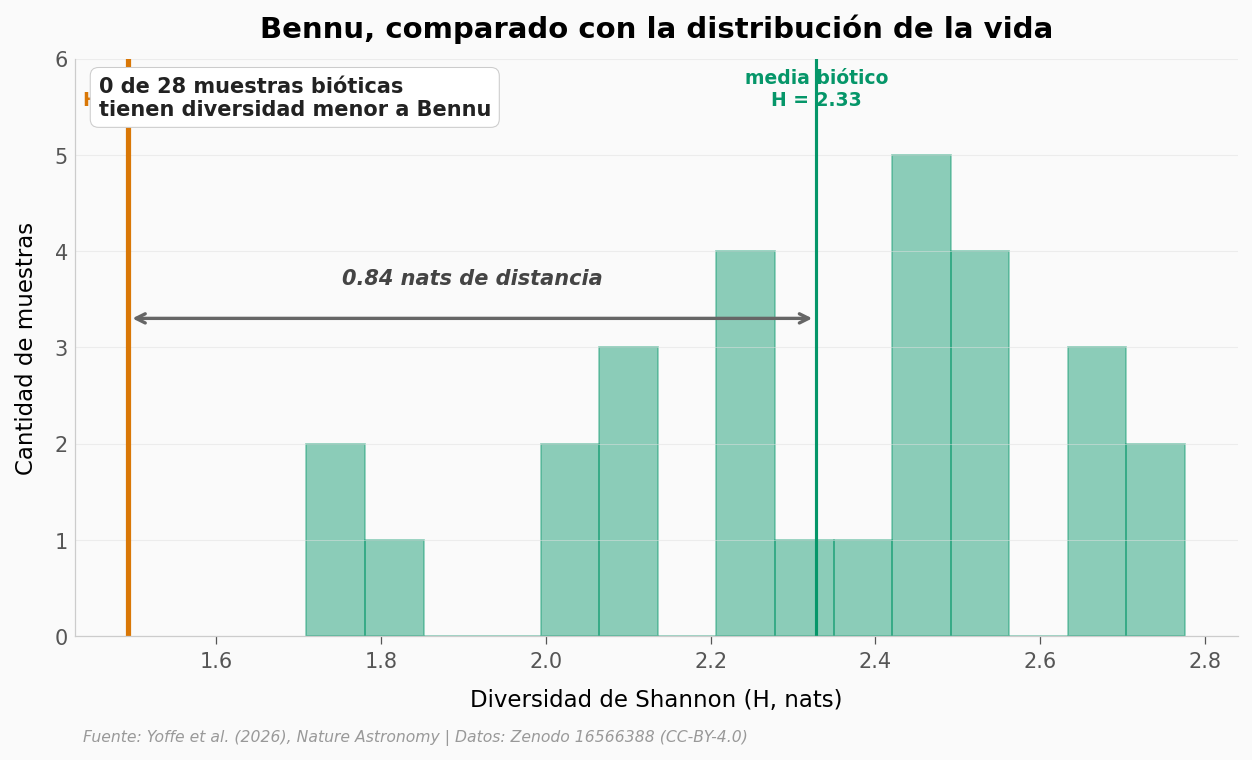

In [7]:
bennu_H = aa[aa['sample'].str.contains('Bennu')]['H'].values[0]
H_biotic = aa[aa['class_label']=='biotic']['H'].values

fig, ax = plt.subplots(figsize=(10, 5))

n, bins, _ = ax.hist(H_biotic, bins=15, color=COLOR_BIOTIC, alpha=0.45,
                      edgecolor=COLOR_BIOTIC, linewidth=0.8, label='Muestras bióticas (n=28)')
y_max = n.max() * 1.20
ax.set_ylim(0, y_max)

mean_biotic = H_biotic.mean()
ax.axvline(x=mean_biotic, color=COLOR_BIOTIC, linewidth=1.5, linestyle='-')
ax.text(mean_biotic, y_max*0.92, f'media biótico\nH = {mean_biotic:.2f}',
        ha='center', fontsize=9, color=COLOR_BIOTIC, fontweight='bold')

ax.axvline(x=bennu_H, color=COLOR_ABIOTIC, linewidth=2.5)
ax.text(bennu_H, y_max*0.92, f'Bennu\nH = {bennu_H:.2f}',
        ha='center', fontsize=9, color=COLOR_ABIOTIC, fontweight='bold')

# Flecha bidireccional
ax.annotate('', xy=(bennu_H, y_max*0.55), xytext=(mean_biotic, y_max*0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.6))
gap = mean_biotic - bennu_H
ax.text((bennu_H + mean_biotic)/2, y_max*0.61,
        f'{gap:.2f} nats de distancia',
        ha='center', fontsize=10, color='#444444', fontweight='bold',
        style='italic')

# ¿Cuántos bióticos están por debajo de Bennu?
n_below = (H_biotic < bennu_H).sum()
ax.text(0.02, 0.97,
        f'{n_below} de {len(H_biotic)} muestras bióticas\n'
        f'tienen diversidad menor a Bennu',
        transform=ax.transAxes, fontsize=10, color='#222222',
        va='top', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#CCCCCC'))

ax.set_xlabel('Diversidad de Shannon (H, nats)', fontsize=11)
ax.set_ylabel('Cantidad de muestras', fontsize=11)
ax.set_title('Bennu, comparado con la distribución de la vida',
             fontsize=14, fontweight='bold', pad=10)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_bennu.png', dpi=200, bbox_inches='tight')
plt.show()


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| Las muestras bióticas tienen mayor diversidad de Shannon que las abióticas (aminoácidos) | ✅ | Diferencia de 0,76 nats (48,5%). Mann-Whitney p < 1e-7. Cohen's d = 2,06 (efecto excepcionalmente grande). |
| Las muestras abióticas tienen, en promedio, **más tipos** distintos de aminoácidos | ✅ | 16,3 vs 14,1. La diferencia es real, pero los abióticos están dominados por glicina/alanina. |
| Bennu (asteroide) tiene baja diversidad pese a sus 27 tipos de aminoácidos | ✅ | H = 1,49. Una sola molécula (glicina) ocupa el 64,2% del total. |
| Las muestras "mixtas" caen en un punto intermedio | ✅ | Media H = 2,04, entre abiótico (1,57) y biótico (2,33). |
| El mismo patrón se replica en **ácidos grasos** | ⚠️ | El paper lo reporta usando un marco probabilístico que ajusta cada muestra a una distribución y propaga incertidumbres. Con entropía de Shannon cruda sobre las abundancias publicadas, en este notebook no obtenemos el mismo resultado (p = 0,76 para ácidos grasos). Es una limitación honesta del enfoque simplificado — la firma diversa de la vida en ácidos grasos requiere la maquinaria completa del paper. |
| La señal de diversidad refleja una firma biosintética fundamental | — | El paper lo plantea como inferencia; los datos sugieren la asociación, no prueban el mecanismo. |

> **Limitaciones que importan:**
> - **Estudio observacional.** El diseño compara muestras pre-existentes; no es un experimento controlado. Los datos muestran asociación entre vida y reparto parejo, no causalidad mecanística.
> - **Sesgo de muestreo.** Las 28 muestras bióticas son mayoritariamente microbios cultivados y fósiles de la Tierra. Si la vida en otro lugar bioquímicamente exótica decide usar 2 o 3 aminoácidos dominantes, este test la marcaría como abiótica.
> - **Réplica parcial.** Confirmamos el resultado sólido para aminoácidos. Para ácidos grasos hace falta el modelo probabilístico del paper.


## Ahora tú

Tres preguntas para hurgar en los datos:

1. **¿Murchison rompe la regla?** Es un meteorito abiótico, pero su H = 2,50 está por encima de muchas
   muestras bióticas. ¿Qué aminoácidos lo dominan? Pista: filtra `aa_ab` por la columna de Murchison y
   ordena las fracciones.

2. **¿Y si miramos la riqueza por separado?** Repite el strip plot pero usando `n_present` en vez de `H`.
   ¿Las clases se siguen separando, o el solapamiento es total? Pista: copia la celda del strip plot
   y cambia `'H'` por `'n_present'`.

3. **¿Qué pasaría con la diversidad si Bennu tuviera 50% glicina en vez de 64%?** Recalcula la entropía
   de Shannon redistribuyendo el exceso de glicina a los otros aminoácidos. Pista: ya tienes `bennu`
   con las fracciones — modifica `frac` y aplica `-sum(p*log(p))`.


In [8]:
# --- EXPERIMENTA AQUÍ ---
# Ejemplo: ¿qué pasa con la diversidad de Bennu si la glicina baja del 64% al 30%?
bennu_test = bennu[['Amino Acid', bennu_col]].copy().reset_index(drop=True)
bennu_test['frac_original'] = bennu_test[bennu_col] / bennu_test[bennu_col].sum()

# Redistribuir el exceso de glicina al resto, en proporción a sus fracciones actuales
target_gly = 0.30
gly_mask = bennu_test['Amino Acid'].str.contains('Gly', case=False, na=False)
gly_actual = bennu_test.loc[gly_mask, 'frac_original'].sum()
excess = gly_actual - target_gly

bennu_test['frac_nueva'] = bennu_test['frac_original'].copy()
bennu_test.loc[gly_mask, 'frac_nueva'] = target_gly
mask_resto = ~gly_mask
bennu_test.loc[mask_resto, 'frac_nueva'] = (
    bennu_test.loc[mask_resto, 'frac_original']
    + excess * bennu_test.loc[mask_resto, 'frac_original'] / bennu_test.loc[mask_resto, 'frac_original'].sum()
)

# Shannon de ambas
def shannon(p):
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())

H_original = shannon(bennu_test['frac_original'].values)
H_simulado = shannon(bennu_test['frac_nueva'].values)
print(f'Bennu original   (glicina {gly_actual*100:.1f}%): H = {H_original:.3f}')
print(f'Bennu simulado   (glicina {target_gly*100:.1f}%): H = {H_simulado:.3f}')
print(f'Diferencia: {H_simulado - H_original:+.3f} nats')
print(f'\n¿Cae todavía debajo de la media biótica ({H_biotic.mean():.3f})?',
      'Sí' if H_simulado < H_biotic.mean() else 'No')


Bennu original   (glicina 64.2%): H = 1.493
Bennu simulado   (glicina 30.0%): H = 2.256
Diferencia: +0.762 nats

¿Cae todavía debajo de la media biótica (2.328)? Sí


---

## Fuentes

**Paper**: [Molecular diversity as a biosignature](https://doi.org/10.1038/s41550-026-02864-z)  
*Nature Astronomy, 2026-05-11*

**Datos**: [Molecular diversity as a biosignature: Amino acids and fatty acid abundances and uncertainty .csv tables](https://doi.org/10.5281/zenodo.16566388)  
*Zenodo · CC-BY-4.0*

*16 afirmaciones del notebook verificadas contra estas fuentes*

---

### Créditos

- **Paper**: Yoffe et al. (2026), *Nature Astronomy*, [DOI 10.1038/s41550-026-02864-z](https://doi.org/10.1038/s41550-026-02864-z)
- **Datos**: Repositorio [Zenodo 16566388](https://doi.org/10.5281/zenodo.16566388), licencia CC-BY-4.0
- **Repositorio del Lab**: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
- **Canal**: [Ciencia a Mordiscos](https://cienciaamordiscos.com)
